In [1]:
!kaggle datasets download algozee/employee-salary-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/algozee/employee-salary-prediction-dataset
License(s): apache-2.0
100% 3.00M/3.00M [00:00<00:00, 170MB/s]



In [2]:
!unzip -q employee-salary-prediction-dataset.zip
!ls

employee-salary-prediction-dataset.zip	sample_data
job_salary_prediction_dataset.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

np.random.seed(42)

In [4]:
df = pd.read_csv("job_salary_prediction_dataset.csv")
df.head(2)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764


In [5]:
df.shape

(250000, 10)

#### Quick EDA

In [6]:
display(df.describe(exclude="object").T)

print("\nMissing values per column:")
display(df.isna().sum())

,count,mean,std,min,25%,50%,75%,max
experience_years,250000.0,10.005408,6.060602,0.0,5.0,10.0,15.0,20.0
skills_count,250000.0,9.997812,5.479288,1.0,5.0,10.0,15.0,19.0
certifications,250000.0,2.491928,1.706475,0.0,1.0,2.0,4.0,5.0
salary,250000.0,145718.080524,37407.952729,31867.0,119358.0,143453.0,169492.0,333046.0



Missing values per column:


,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


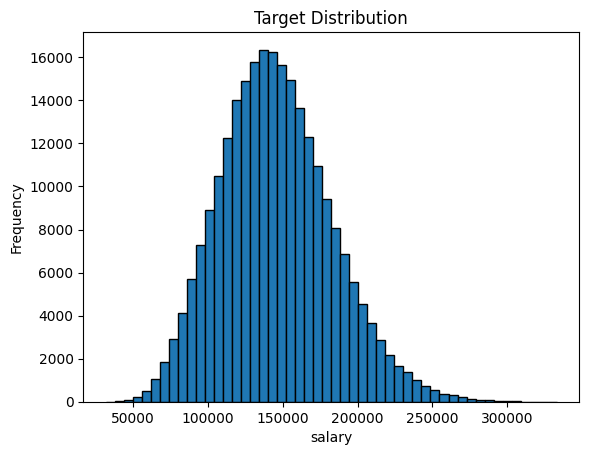

In [7]:
plt.figure()
plt.hist(df["salary"], bins=50, edgecolor="black")
plt.title("Target Distribution")
plt.xlabel("salary")
plt.ylabel("Frequency")
plt.show()

In [8]:
cols = df.select_dtypes("object").columns.tolist()
cols

['job_title',
 'education_level',
 'industry',
 'company_size',
 'location',
 'remote_work']

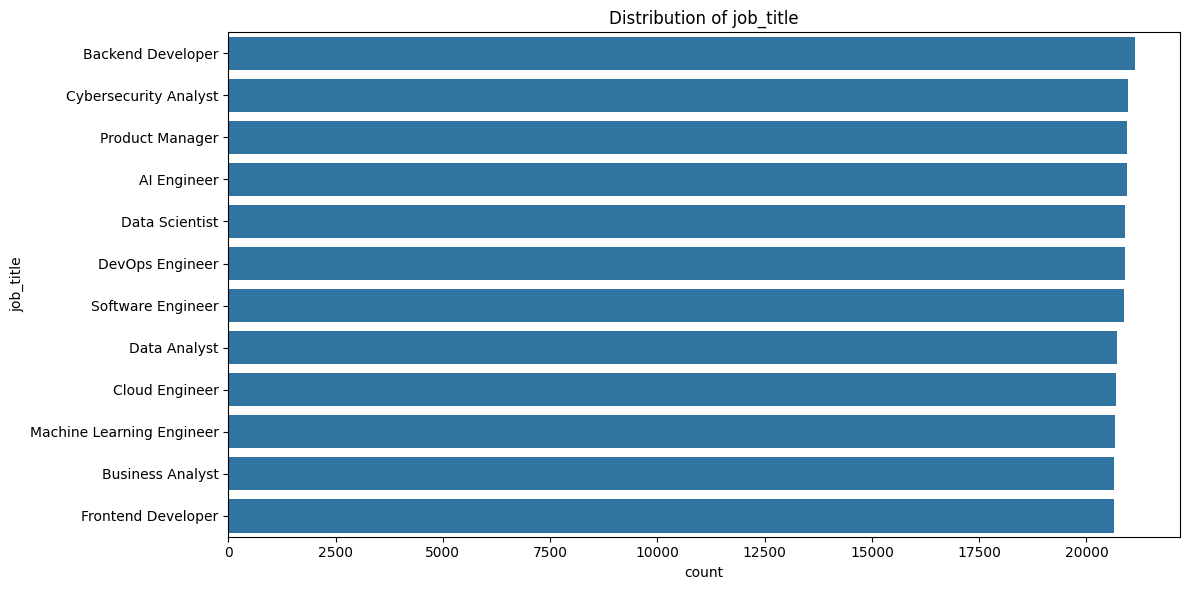

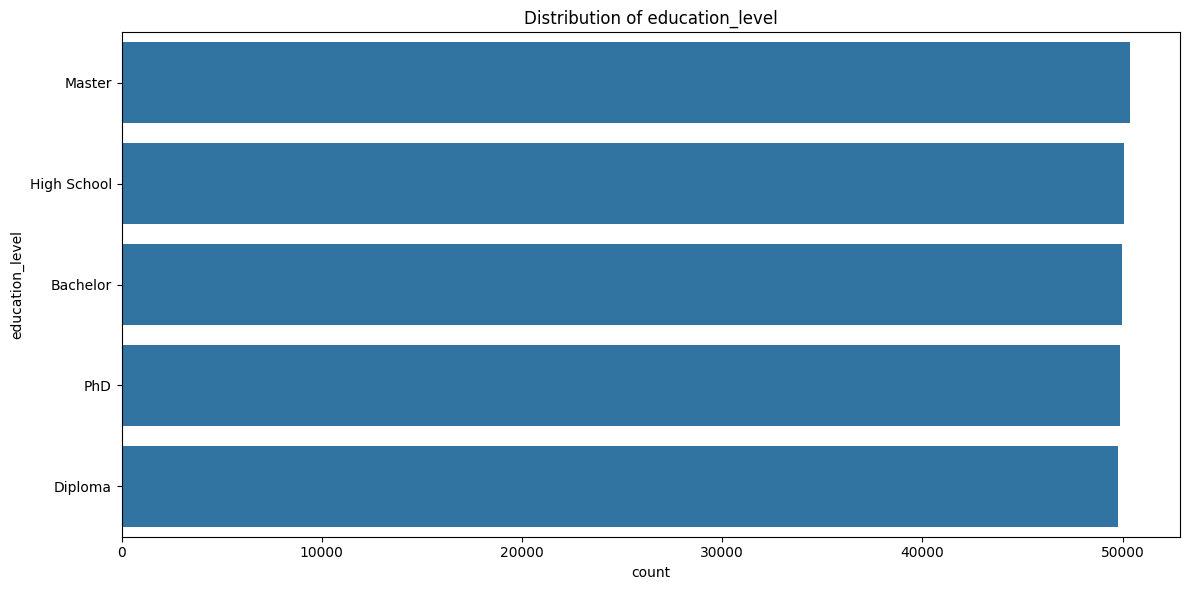

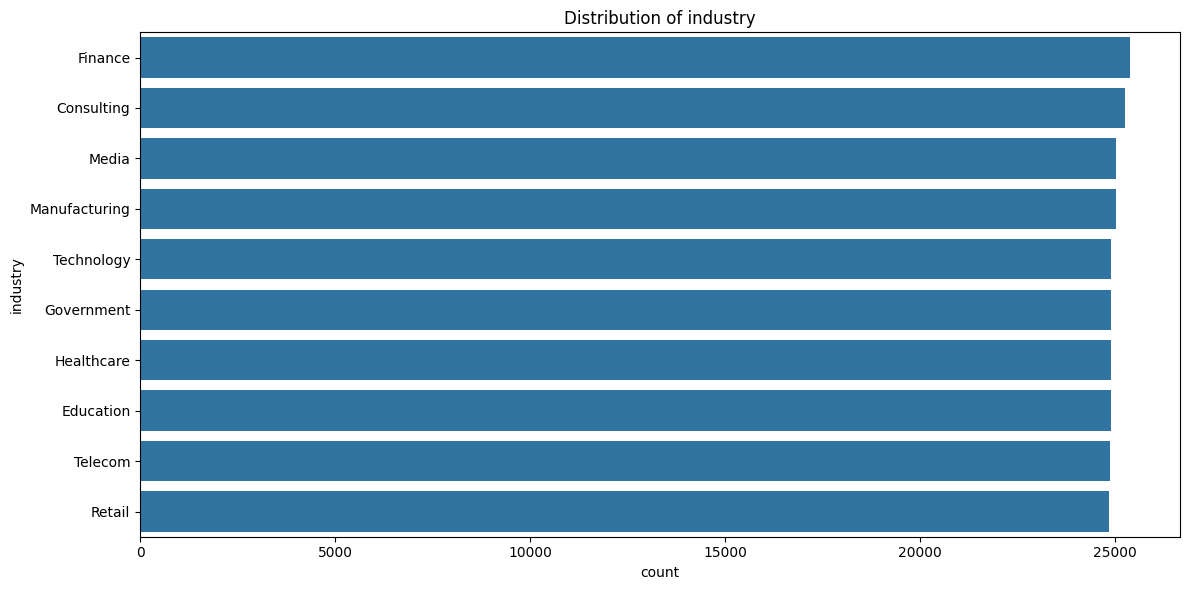

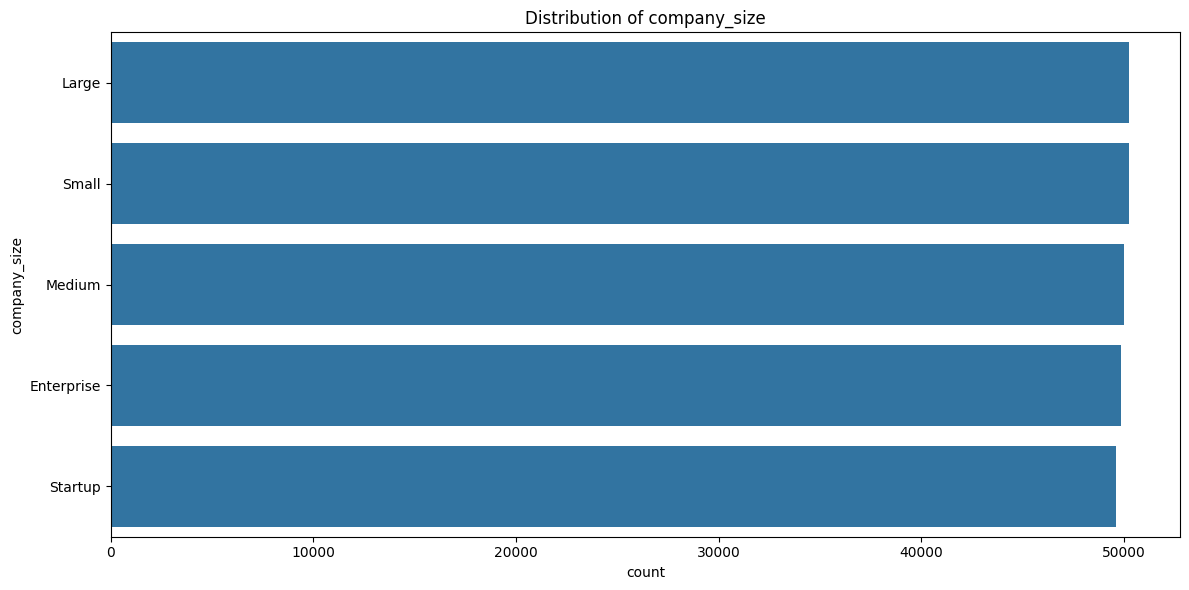

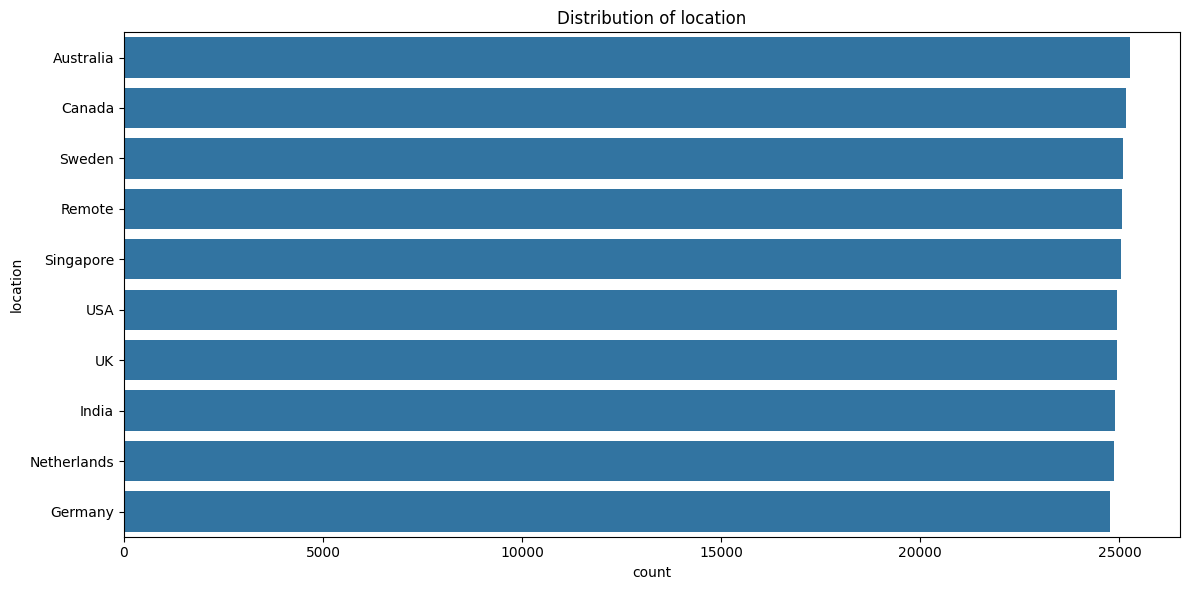

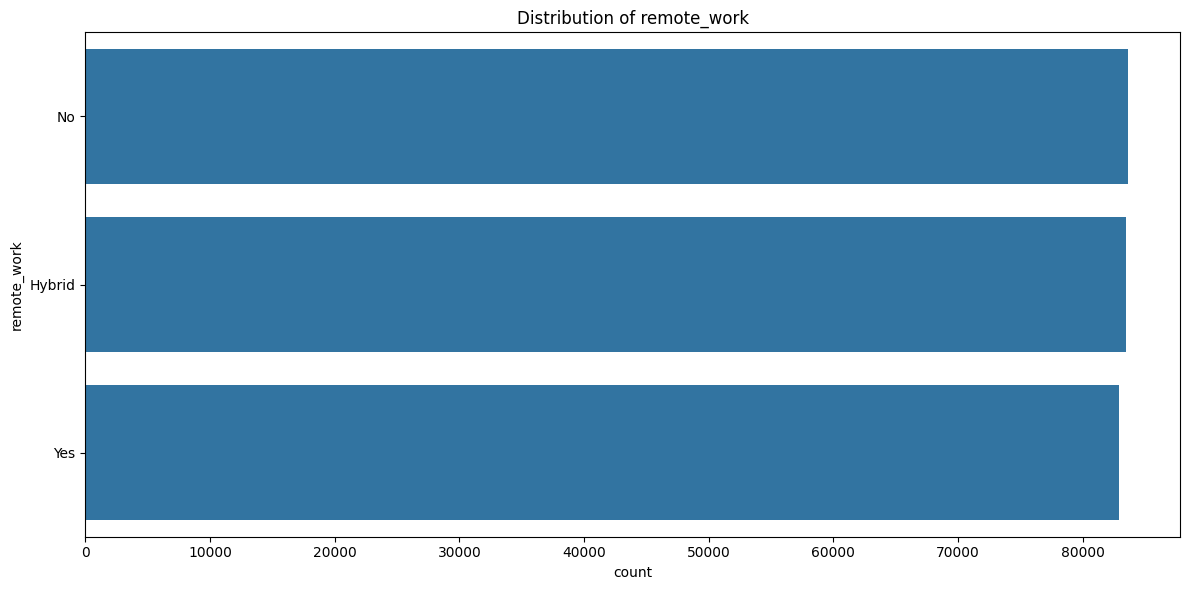

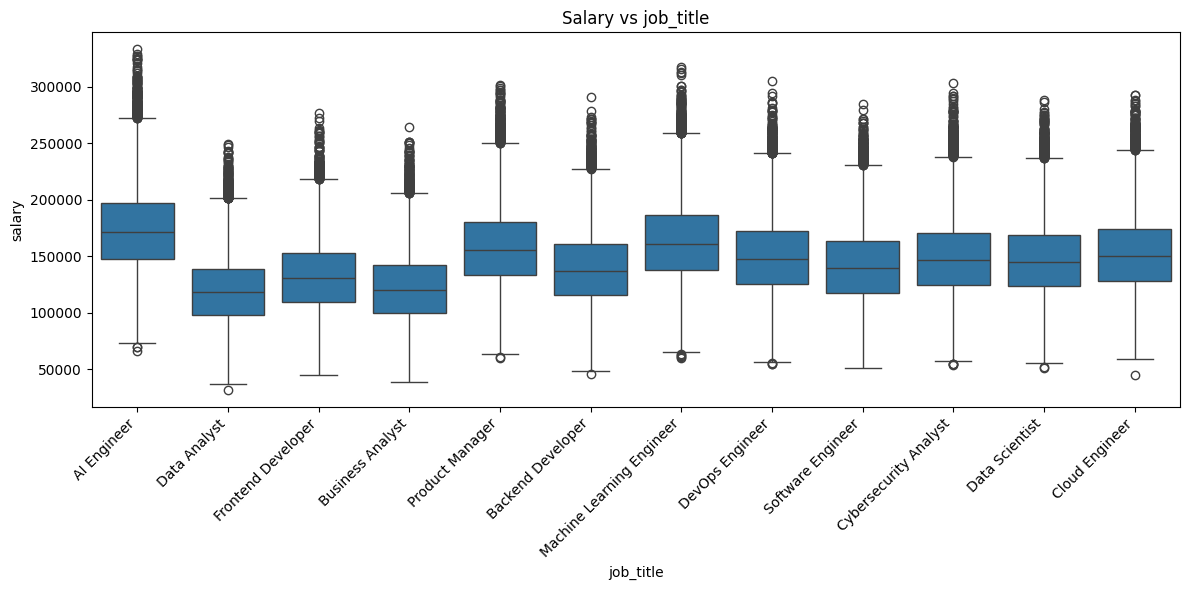

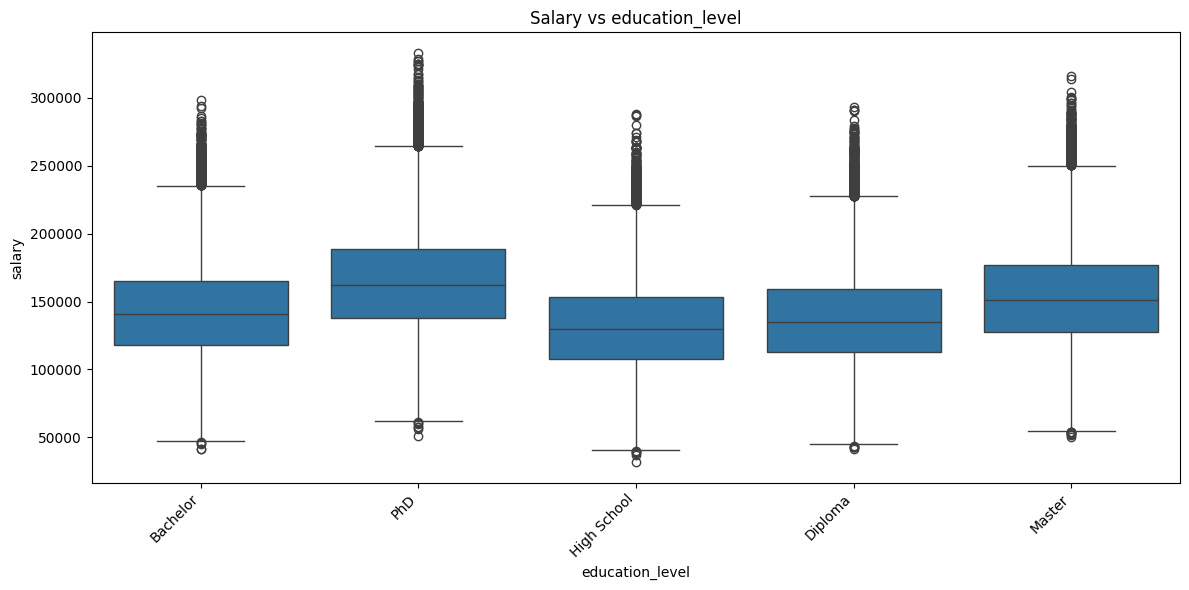

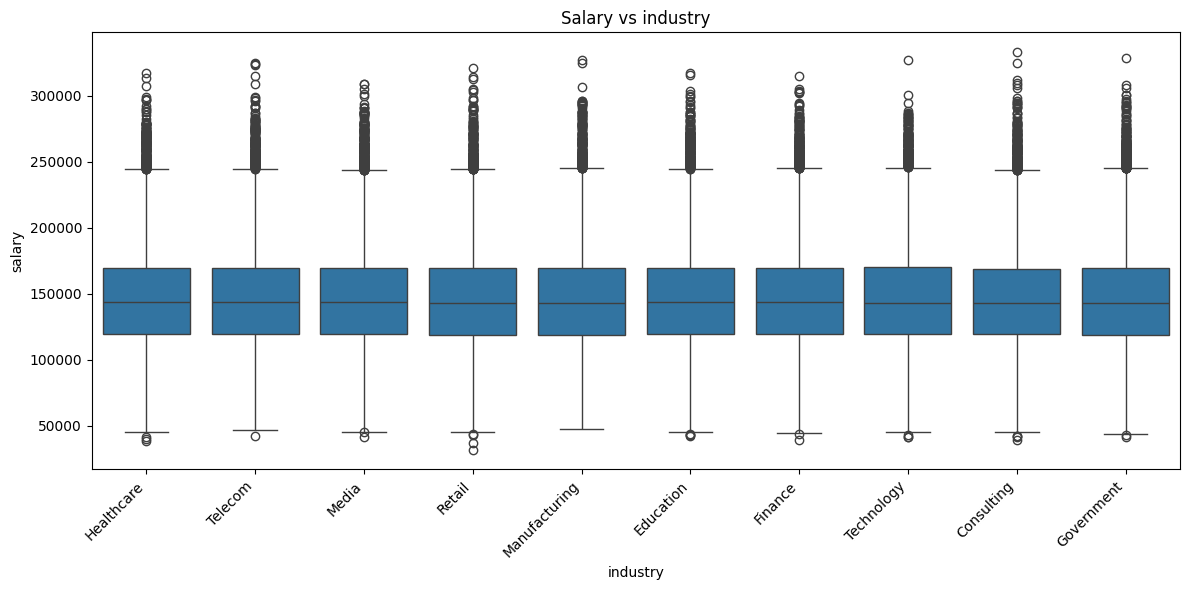

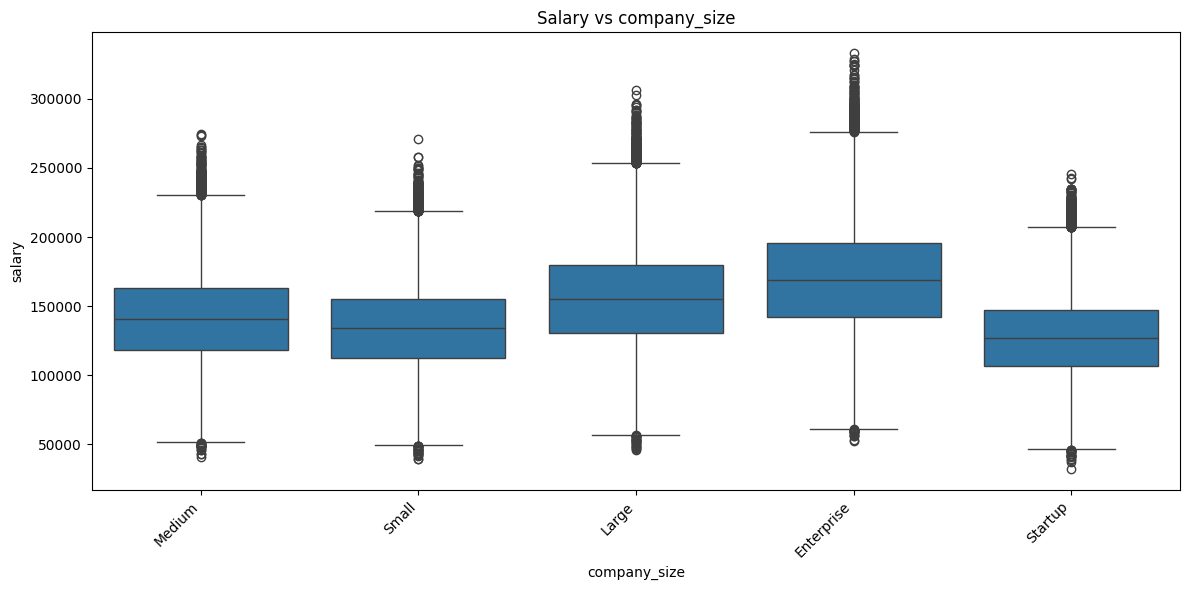

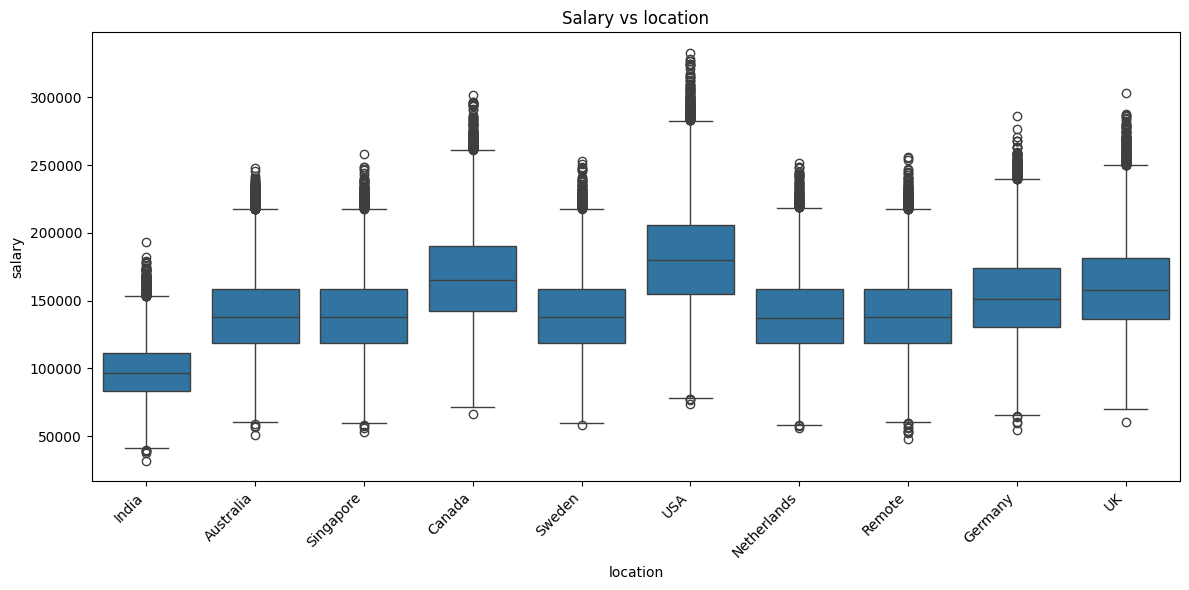

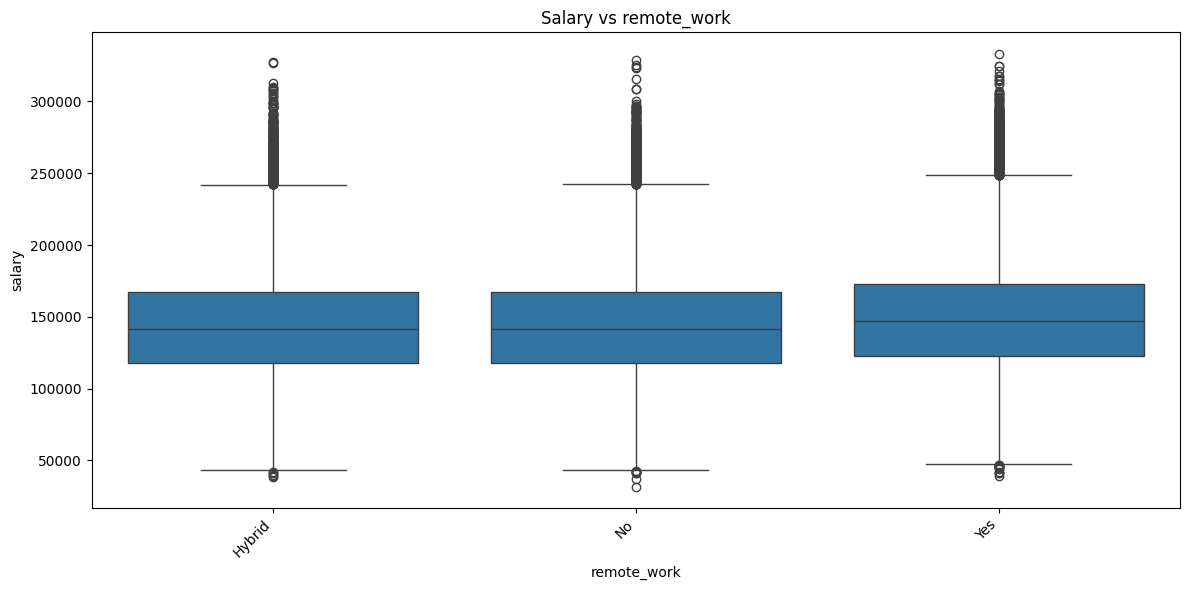

In [9]:
for col in cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

for col in cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=col, y='salary')
    plt.title(f'Salary vs {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#### Train/Test Split

In [10]:
x = df.drop("salary", axis=1)
y = df["salary"]

In [11]:
x = pd.get_dummies(x, drop_first=True, dtype=int)

print(x.shape)

x.head(1)

(250000, 42)


,experience_years,skills_count,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

Train shape: (200000, 42) Test shape: (50000, 42)


In [ ]:
def adjusted_r2(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    return r2, 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

def eval_regression(y_true, y_pred, n_feature, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y_true, y_pred)
    r2, adj = adjusted_r2(y_true, y_pred, n_feature)
    return {"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2, "Adj_R2": adj}

In [14]:
def residual_plots(y_true, y_pred, max_points=8000):
    residuals = (y_true - y_pred).to_numpy() if hasattr(y_true, "to_numpy") else (y_true - y_pred)
    
    y_pred_arr = np.array(y_pred)
    
    if len(residuals) > max_points:
        idx = np.random.choice(len(residuals), size=max_points, replace=False)
        residuals = residuals[idx]
        y_pred_arr = y_pred_arr[idx]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0, 0].scatter(y_pred_arr, residuals, alpha=0.35)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals vs Predicted")
    axes[0, 0].set_xlabel("Predicted")
    axes[0, 0].set_ylabel("Residuals")

    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title("Q-Q Plot (Normality)")

    axes[1, 0].hist(residuals, bins=40, edgecolor="black")
    axes[1, 0].set_title("Residual Distribution")
    axes[1, 0].set_xlabel("Residual")

    std_res = residuals / (np.std(residuals) + 1e-12)
    axes[1, 1].scatter(y_pred_arr, np.sqrt(np.abs(std_res)), alpha=0.35)
    axes[1, 1].set_title("Scale-Location Plot")
    axes[1, 1].set_xlabel("Predicted")
    axes[1, 1].set_ylabel("sqrt(|standardized residual|)")

    plt.tight_layout()
    plt.show()
    
    
    shapiro_p = stats.shapiro(residuals[:5000]).pvalue
    jb_statem, jb_p = stats.jarque_bera(residuals)
    
    print(f"Shapiro-Wilk p-value (normality): {shapiro_p:.4g}")
    print(f"Jarque-Bera p-value (normality): {jb_p:.4g}")

    return residuals

#### Linear Regression (with preprocessing pipeline)

In [15]:
linear_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(x_train, y_train)
y_pred_linear = linear_pipeline.predict(x_test)

In [16]:
results = []

results.append(eval_regression(y_test, y_pred_linear, n_feature=x_test.shape[1], name="LinearRegression"))

pd.DataFrame(results)

,Model,MSE,RMSE,MAE,R2,Adj_R2
0,LinearRegression,5.077308e+07,7125.522904,5436.096937,0.963469,0.963438


#### Residual diagnostics

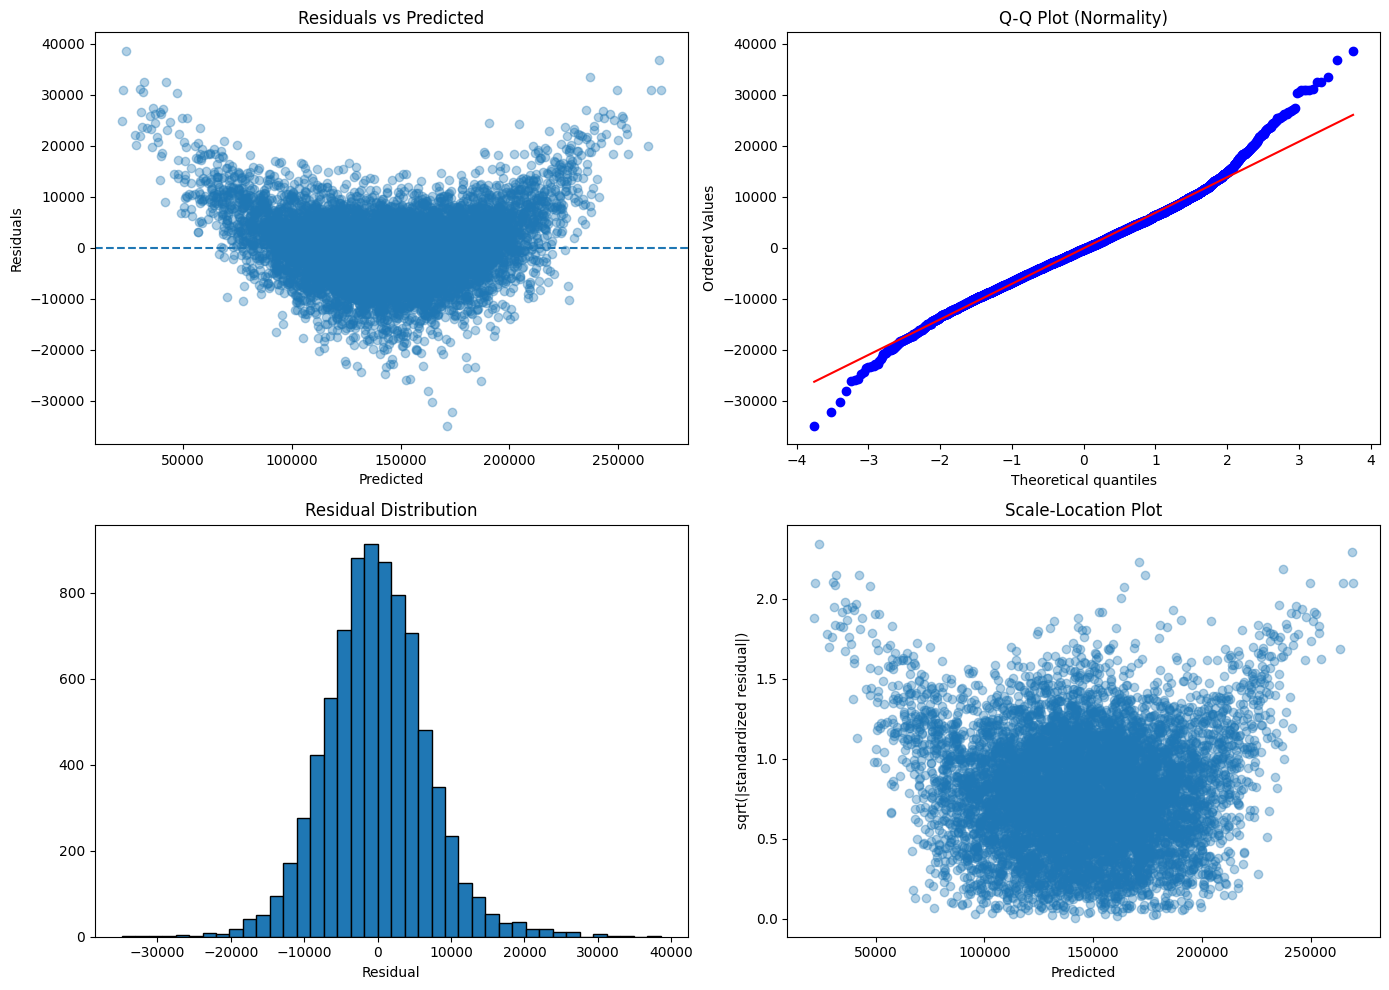

Shapiro-Wilk p-value (normality): 3.757e-24
Jarque-Bera p-value (normality): 2.838e-182


In [17]:
residual_lin = residual_plots(y_test, y_pred_linear)

In [18]:
imp = SimpleImputer(strategy="median")
scaler = StandardScaler()

x_train_imp = imp.fit_transform(x_train)
x_test_imp  = imp.transform(x_test)

X_train_scaled = scaler.fit_transform(x_train_imp)
X_test_scaled  = scaler.transform(x_test_imp)

In [19]:
X_test_scaled  = scaler.transform(x_test_imp)
y_pred_test = linear_pipeline.predict(X_test_scaled) 

residual_lin = y_test - y_pred_test 
X_bp = sm.add_constant(X_test_scaled)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residual_lin, X_bp)

print(f"Breusch–Pagan p-value (heteroscedasticity): {bp_pvalue:.4g}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


Breusch–Pagan p-value (heteroscedasticity): 0


#### Ridge

In [20]:
ridge_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=0.7))
])

ridge_pipeline.fit(x_train, y_train)
y_pred_ridge = ridge_pipeline.predict(x_test)

results.append(eval_regression(y_test, y_pred_ridge, n_feature=x_test.shape[1], name="Ridge(alpha=0.7)"))

pd.DataFrame(results).sort_values("RMSE")

,Model,MSE,RMSE,MAE,R2,Adj_R2
0,LinearRegression,5.077308e+07,7125.522904,5436.096937,0.963469,0.963438
1,Ridge(alpha=0.7),5.077309e+07,7125.523673,5436.094259,0.963469,0.963438


#### PCA + Linear Regression

In [21]:
pca_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("model", LinearRegression())
])

pca_pipe.fit(x_train, y_train)
y_pred_pca = pca_pipe.predict(x_test)

n_comp = pca_pipe.named_steps["pca"].n_components_
results.append(eval_regression(y_test, y_pred_pca, n_feature=n_comp, name=f"PCA(0.95)+Linear (k={n_comp})"))

pd.DataFrame(results).sort_values("RMSE")

,Model,MSE,RMSE,MAE,R2,Adj_R2
0,LinearRegression,5.077308e+07,7125.522904,5436.096937,0.963469,0.963438
1,Ridge(alpha=0.7),5.077309e+07,7125.523673,5436.094259,0.963469,0.963438
2,PCA(0.95)+Linear (k=36),2.749092e+08,16580.386696,13119.021567,0.802204,0.802062


#### Outliers: detect + handle

1. Z-score outliers on y_train

In [22]:
y_train_arr = y_train.to_numpy()
z = np.abs((y_train_arr - y_train_arr.mean()) / (y_train_arr.std() + 1e-12))

z_outliers = z > 3
print("Z-score outliers in y_train:", int(z_outliers.sum()))

Z-score outliers in y_train: 873


2. IQR outliers on y_train

In [23]:
q1, q3 = np.percentile(y_train_arr, [25, 75])
iqr = q3 - q1

low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_outliers = (y_train_arr < low) | (y_train_arr > high)

print("IQR outliers in y_train:", int(iqr_outliers.sum()))

IQR outliers in y_train: 1865


3. Residual-based outliers using linear residuals on train

In [25]:
y_pred_train_lin = linear_pipeline.predict(x_train)

res_train = y_train - y_pred_train_lin
res_std = res_train.std()

res_outliers = np.abs(res_train) > 3 * res_std

print("Residual-based outliers in train:", int(res_outliers.sum()))

Residual-based outliers in train: 1990


In [27]:
x_train_clean = x_train.loc[~res_outliers].copy()
y_train_clean = y_train.loc[~res_outliers].copy()

linear_pipeline_clean = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline_clean.fit(x_train_clean, y_train_clean)
y_pred_clean = linear_pipeline_clean.predict(x_test)

results.append(eval_regression(y_test, y_pred_clean, x_test.shape[1], "Linear (remove res outliers"))
pd.DataFrame(results).sort_values("RMSE")

,Model,MSE,RMSE,MAE,R2,Adj_R2
0,LinearRegression,5.077308e+07,7125.522904,5436.096937,0.963469,0.963438
1,Ridge(alpha=0.7),5.077309e+07,7125.523673,5436.094259,0.963469,0.963438
3,Linear (remove res outliers,5.087280e+07,7132.516879,5426.125421,0.963397,0.963367
2,PCA(0.95)+Linear (k=36),2.749092e+08,16580.386696,13119.021567,0.802204,0.802062


In [28]:
huber_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", HuberRegressor(epsilon=1.30))
])

huber_pipe.fit(x_train, y_train)
y_pred_huber = huber_pipe.predict(x_test)
results.append(eval_regression(y_test, y_pred_huber, x_test.shape[1], "HuberRegressor"))

pd.DataFrame(results).sort_values("RMSE")

,Model,MSE,RMSE,MAE,R2,Adj_R2
0,LinearRegression,5.077308e+07,7125.522904,5436.096937,0.963469,0.963438
1,Ridge(alpha=0.7),5.077309e+07,7125.523673,5436.094259,0.963469,0.963438
3,Linear (remove res outliers,5.087280e+07,7132.516879,5426.125421,0.963397,0.963367
4,HuberRegressor,5.096239e+07,7138.794812,5423.144177,0.963333,0.963302
2,PCA(0.95)+Linear (k=36),2.749092e+08,16580.386696,13119.021567,0.802204,0.802062
